# 2 - Label Coverage & Class Imbalance

This notebook focuses on which labels exist across waves, their coverage patterns, and class distribution.

## Import libraries and defining paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import get_data_root, COLORS, WAVE_LABELS, WAVE_KEYS, WAVE_TO_DIR, set_paper_style

DATA_ROOT = get_data_root()
set_paper_style()


## Load the data

In [ ]:
from utils import (
    load_wave_esm_userinfo,
    normalize_label_series, get_label_series,
    SHARED_LABELS, W1_W2_ONLY, W1_ONLY, W2_ONLY, W3_ONLY, ALL_LABELS,
    COVERAGE_BY_WAVE,
)

In [ ]:
esm_by_wave, _, esm_all = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=False,
    include_study_day=True,
)

## Visuals

### Label coverage matrix

This heatmap summarizes the pattern across waves so differences and missingness are easy to compare.


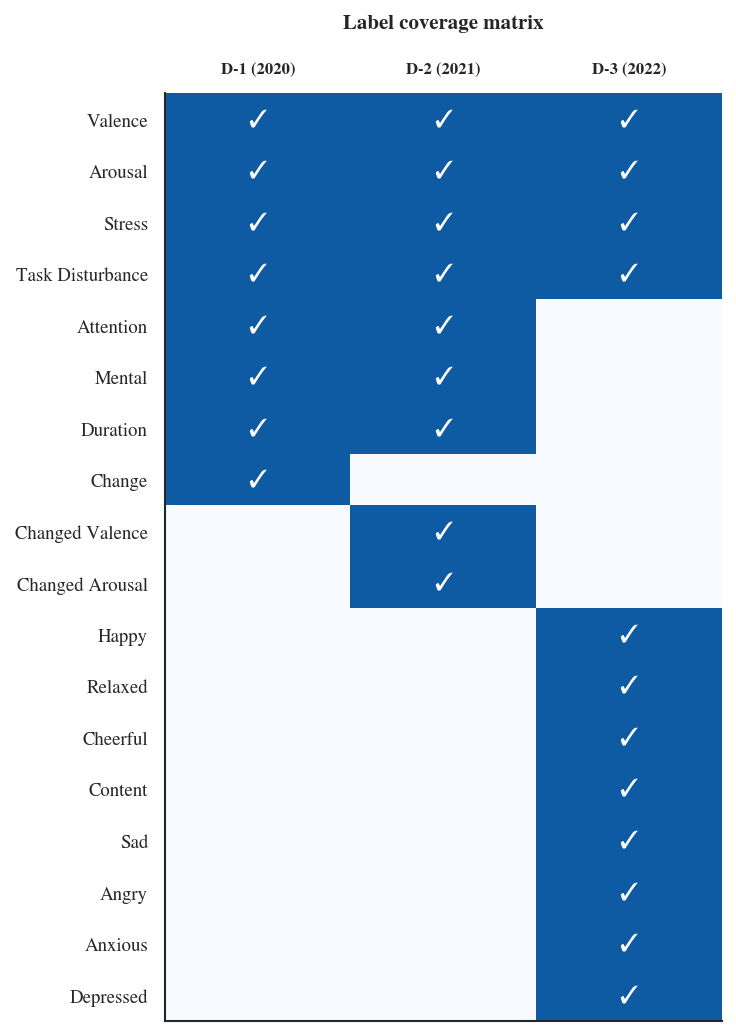

In [ ]:
all_labels = ALL_LABELS
coverage = COVERAGE_BY_WAVE
mat = np.array([[1 if lbl in coverage[dk] else 0 for dk in WAVE_KEYS] for lbl in all_labels])

fig, ax = plt.subplots(figsize=(5, 7))
ax.imshow(mat, cmap="Blues", aspect="auto", vmin=0, vmax=1.2)
ax.spines["top"].set_color("1")
ax.spines["right"].set_color("1")
ax.set_xticks(range(len(WAVE_KEYS)))
ax.set_xticklabels(WAVE_LABELS, fontweight="bold")
ax.set_yticks(range(len(all_labels)))
ax.set_yticklabels(all_labels, fontsize=9)
ax.xaxis.set_tick_params(labeltop=True, labelbottom=False)

for r in range(len(all_labels)):
    for c in range(len(WAVE_KEYS)):
        sym = "✓" if mat[r, c] else ""
        ax.text(c, r, sym, ha="center", va="center",
                fontsize=12, color="white" if mat[r, c] else "#AAAAAA")
                
ax.set_title("Label coverage matrix", fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

### Helper - Plot a single affect distribution

In [5]:
SCORE_LEVELS = np.arange(-3, 4)
MARKERS = ["o", "s", "D"]

### Affect distributions
Insight: Compares shared-label distributions across waves.

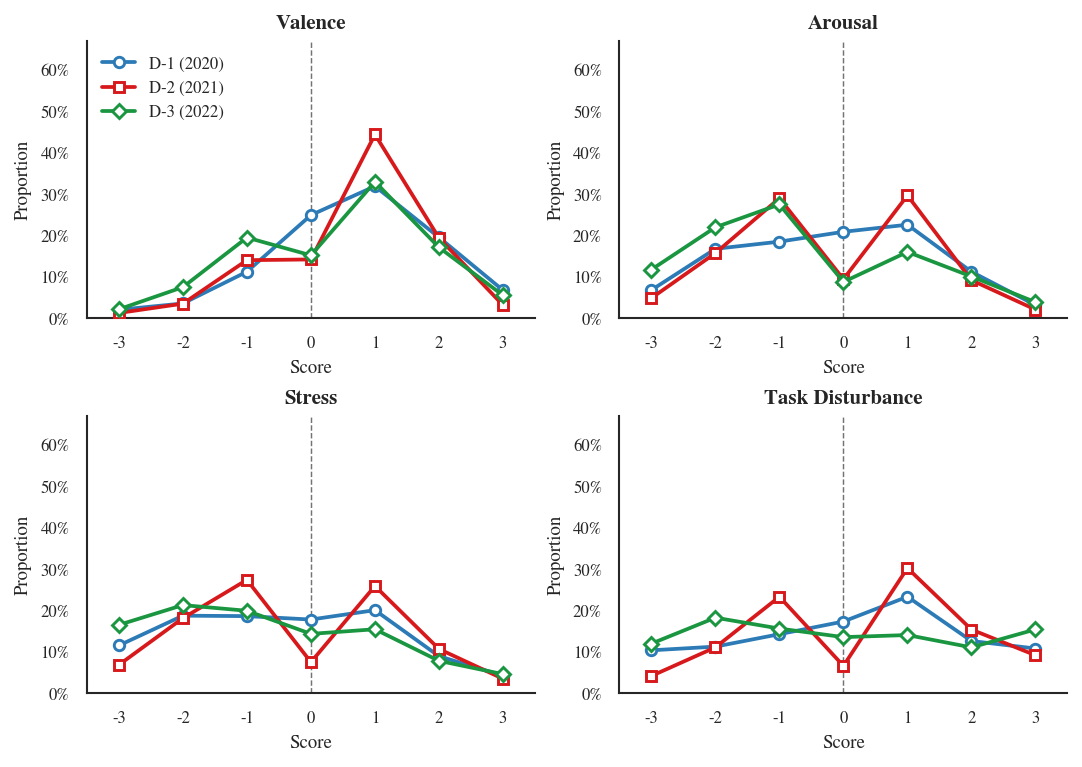

In [6]:
all_labels = list(dict.fromkeys(ALL_LABELS))

all_props: dict[str, dict[str, np.ndarray]] = {}
global_max = 0.0
for label in all_labels:
    all_props[label] = {}
    for key in WAVE_KEYS:
        data = get_label_series(esm_by_wave.get(key, pd.DataFrame()), label)
        counts = data.round().value_counts(normalize=True).reindex(SCORE_LEVELS, fill_value=0.0)
        proportions = counts.values.astype(float)
        all_props[label][key] = proportions
        global_max = max(global_max, proportions.max())

y_max = np.ceil(global_max * 20) / 20 + 0.02

fig, axes = plt.subplots(2, 2, figsize=(7.1, 5.0), constrained_layout=True)
axes = axes.ravel()

for ax, label in zip(axes, SHARED_LABELS):
    any_data = False
    for k_idx, key in enumerate(WAVE_KEYS):
        if key not in all_props.get(label, {}):
            continue
        any_data = True
        proportions = all_props[label][key]
        proportions_plot = np.where(proportions == 0, np.nan, proportions)
        ax.plot(
            SCORE_LEVELS, proportions_plot, color=COLORS[key], lw=1.8,
            marker=MARKERS[k_idx], markersize=5, markerfacecolor="white",
            markeredgecolor=COLORS[key], markeredgewidth=1.4,
            label=WAVE_LABELS[k_idx], zorder=3,
        )

    if not any_data:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_axis_off()
        continue

    ax.axvline(0, color="0.45", ls="--", lw=0.7)
    ax.set_xlim(-3.5, 3.5)
    ax.set_xticks(SCORE_LEVELS)
    ax.set_xticklabels([str(v) for v in SCORE_LEVELS], rotation=0)
    ax.set_xlabel("Score")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, y_max)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(label, fontweight="bold")

axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.show()

### Stress Score Distribution by Wave

This line plot compares the stress score distribution shape across D-1, D-2, and D-3.


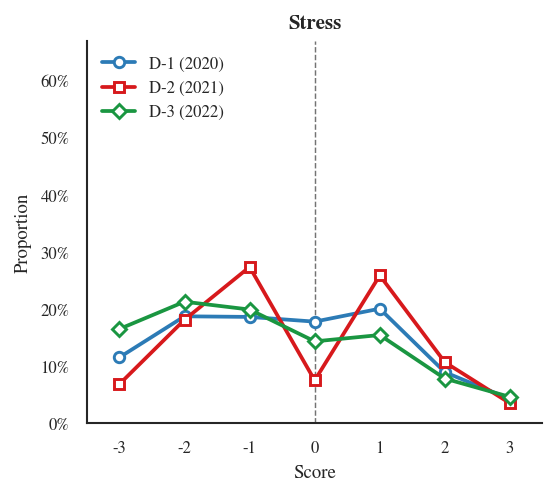

In [7]:
fig, ax = plt.subplots(figsize=(3.6, 3.2), constrained_layout=True)

has_stress = False
for k_idx, key in enumerate(WAVE_KEYS):
    if key not in all_props.get("Stress", {}):
        continue
    has_stress = True
    proportions = all_props["Stress"][key]
    proportions_plot = np.where(proportions == 0, np.nan, proportions)
    ax.plot(
        SCORE_LEVELS, proportions_plot, color=COLORS[key], lw=1.8,
        marker=MARKERS[k_idx], markersize=5, markerfacecolor="white",
        markeredgecolor=COLORS[key], markeredgewidth=1.4,
        label=WAVE_LABELS[k_idx], zorder=3,
    )

if has_stress:
    ax.axvline(0, color="0.45", ls="--", lw=0.7)
    ax.set_xlim(-3.5, 3.5)
    ax.set_xticks(SCORE_LEVELS)
    ax.set_xticklabels([str(v) for v in SCORE_LEVELS], rotation=0)
    ax.set_xlabel("Score")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, y_max)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title("Stress", fontweight="bold")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
else:
    ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
    ax.set_axis_off()

plt.show()

### Non-Shared Label Distributions

These small multiples show score distributions for labels that are not shared across all waves.


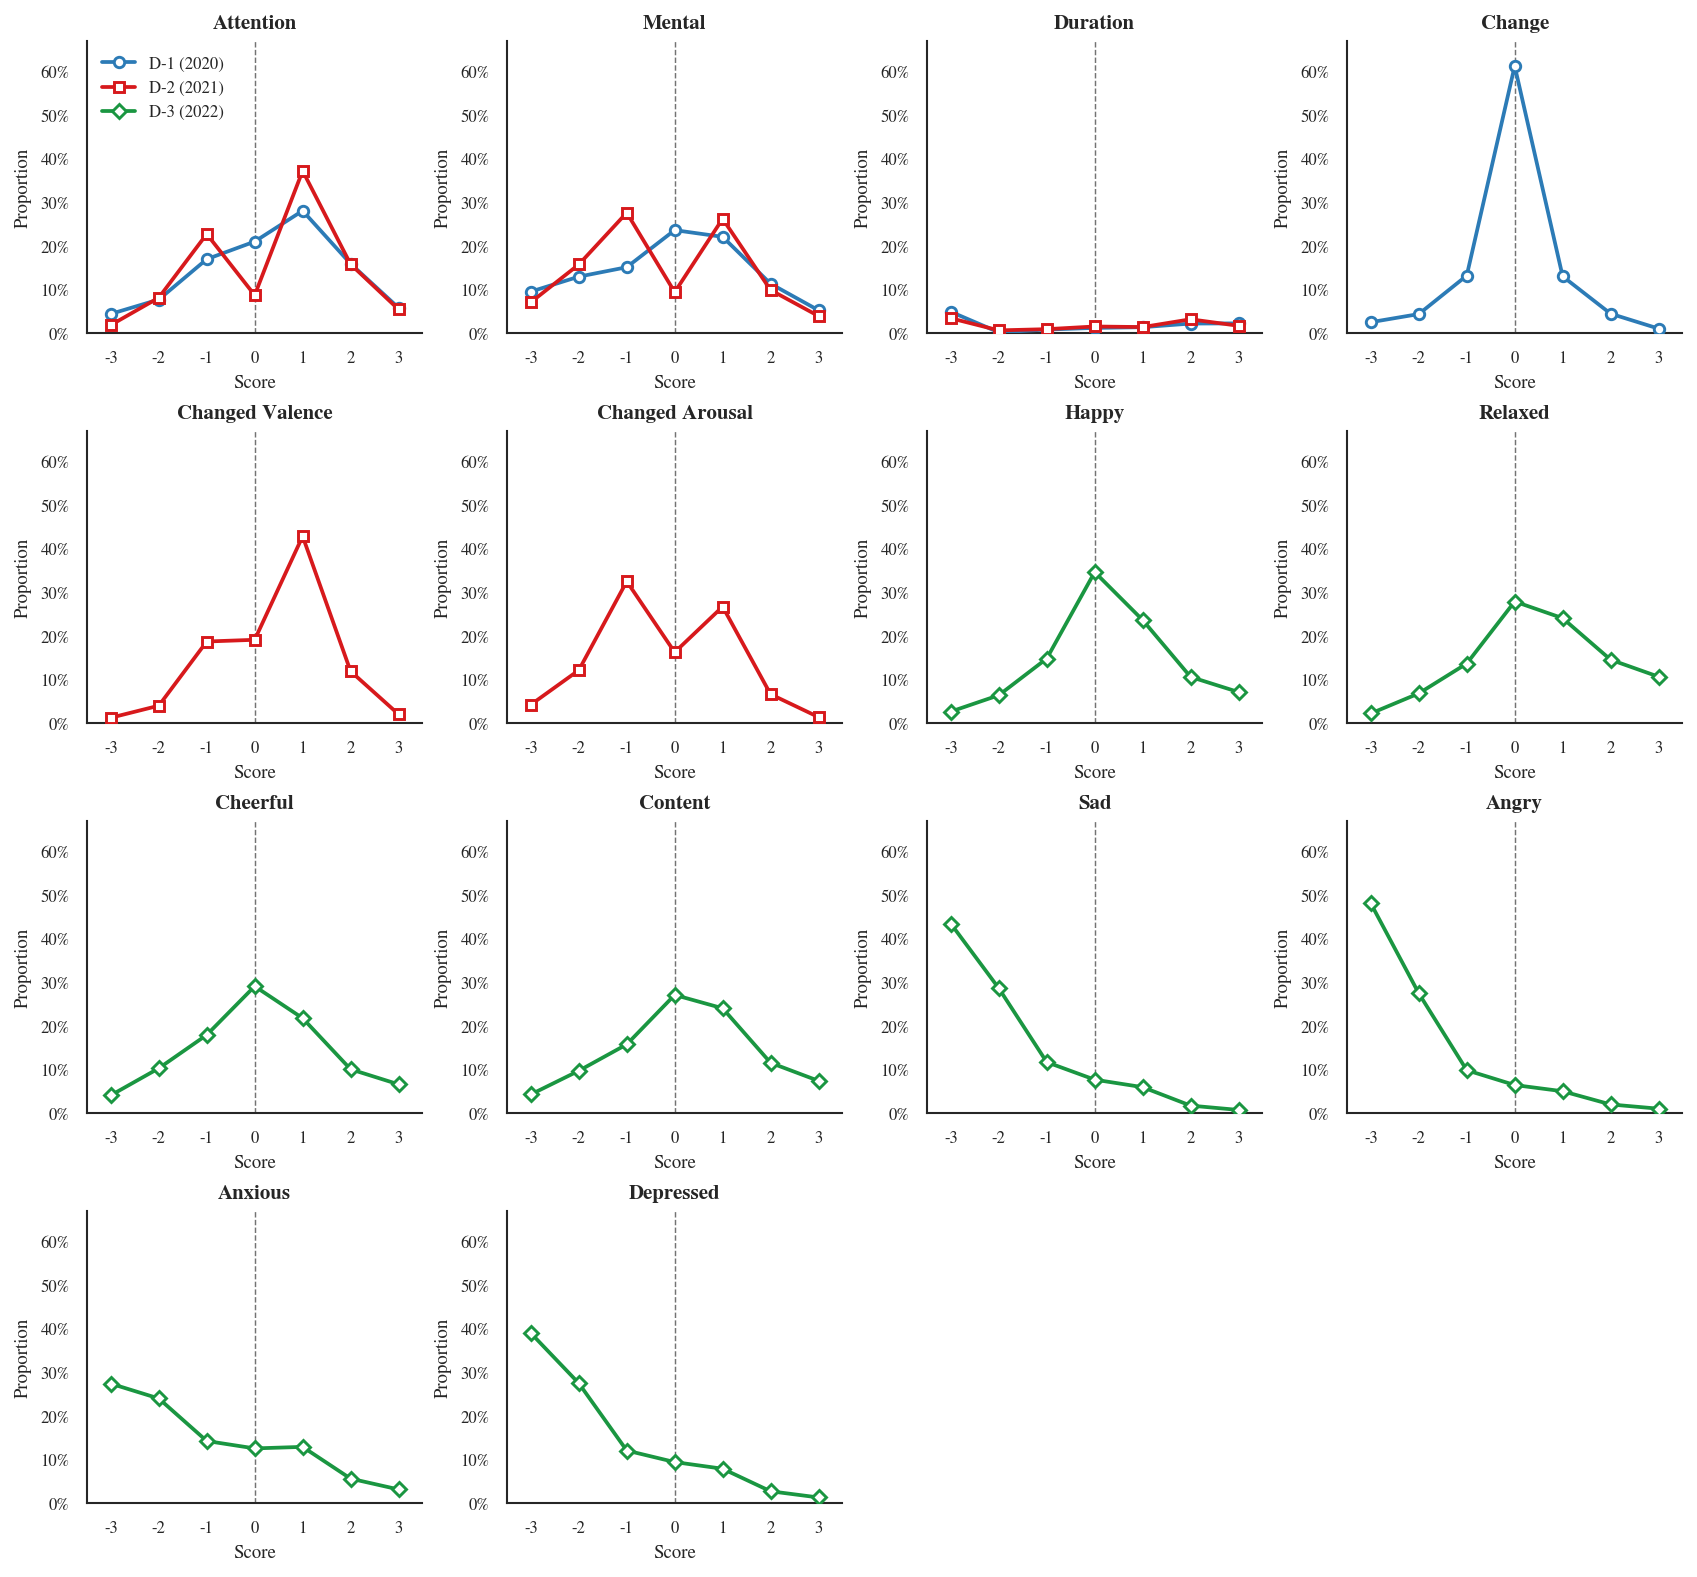

In [ ]:
other_labels = [lbl for lbl in (W1_W2_ONLY + W1_ONLY + W2_ONLY + W3_ONLY)]
n_cols = 4
n_rows = int(np.ceil(len(other_labels) / n_cols)) if other_labels else 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.2, 2.6 * n_rows), constrained_layout=True)
axes = np.array(axes).ravel()

any_other = False
legend_ax = None
for ax, label in zip(axes, other_labels):
    has_data = False
    for k_idx, key in enumerate(WAVE_KEYS):
        if key not in all_props.get(label, {}):
            continue
        has_data = True
        proportions = all_props[label][key]
        proportions_plot = np.where(proportions == 0, np.nan, proportions)
        ax.plot(
            SCORE_LEVELS, proportions_plot, color=COLORS[key], lw=1.8,
            marker=MARKERS[k_idx], markersize=5, markerfacecolor="white",
            markeredgecolor=COLORS[key], markeredgewidth=1.4,
            label=WAVE_LABELS[k_idx], zorder=3,
        )

    if has_data:
        ax.axvline(0, color="0.45", ls="--", lw=0.7)
        ax.set_xlim(-3.5, 3.5)
        ax.set_xticks(SCORE_LEVELS)
        ax.set_xticklabels([str(v) for v in SCORE_LEVELS], rotation=0)
        ax.set_xlabel("Score")
        ax.set_ylabel("Proportion")
        ax.set_ylim(0, y_max)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
        ax.set_title(label, fontweight="bold")
        if legend_ax is None:
            legend_ax = ax
    else:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_axis_off()

    any_other = any_other or has_data

for ax in axes[len(other_labels):]:
    ax.set_axis_off()

if any_other and legend_ax is not None:
    legend_ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

### Shared Label Distribution Profiles

This panel compares shared affect-label distribution profiles side-by-side across waves.


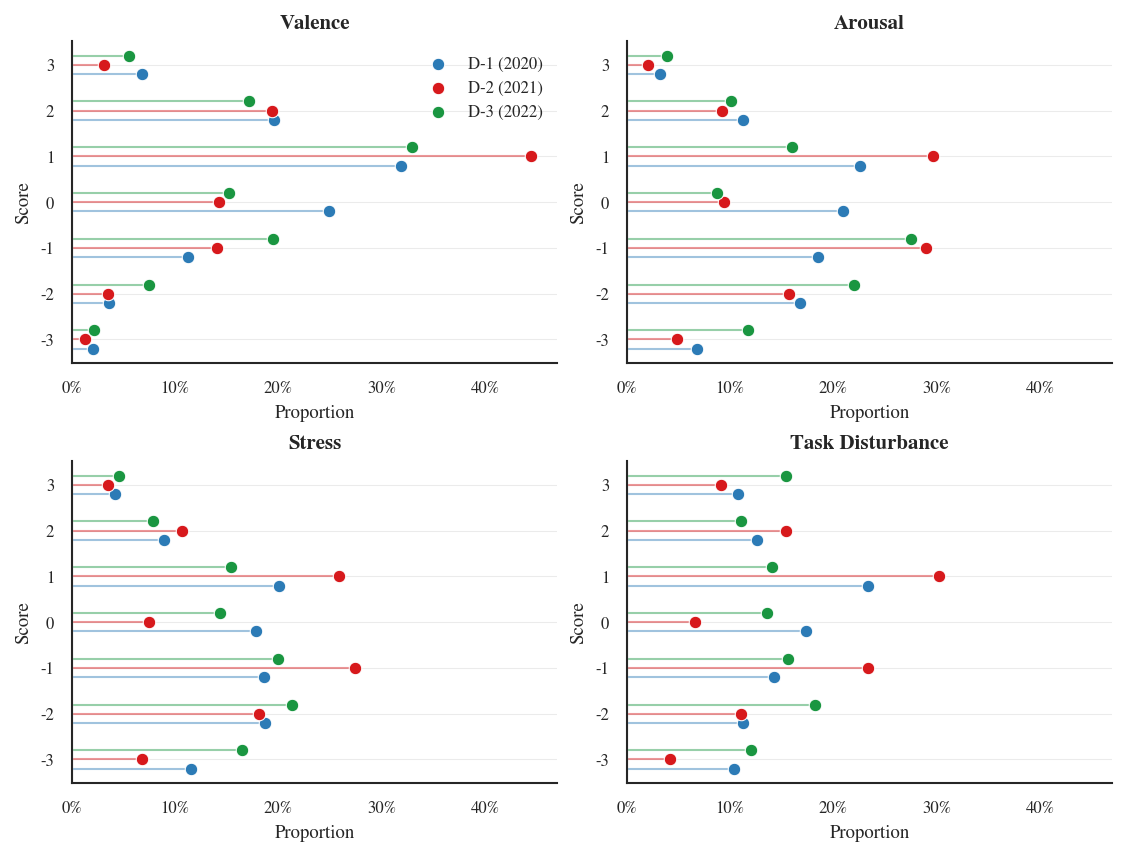

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.6), constrained_layout=True)
axes = axes.ravel()
n_waves = len(WAVE_KEYS)
offset_step = 0.2

# Reuse all_props computed above — just derive the x-axis scale from SHARED_LABELS only
x_max2 = np.ceil(
    max(all_props[lbl][key].max() for lbl in SHARED_LABELS for key in WAVE_KEYS if key in all_props.get(lbl, {}))
    * 20
) / 20 + 0.02

for ax, label in zip(axes, SHARED_LABELS):
    any_data = False
    for k_idx, key in enumerate(WAVE_KEYS):
        if key not in all_props.get(label, {}):
            continue
        any_data = True
        proportions = all_props[label][key]
        y_positions = SCORE_LEVELS + (k_idx - (n_waves - 1) / 2) * offset_step
        for yp, prop in zip(y_positions, proportions):
            ax.plot([0, prop], [yp, yp], color=COLORS[key], lw=1.0, alpha=0.45)
        ax.scatter(proportions, y_positions, color=COLORS[key], s=36, zorder=4,
                   edgecolors="white", linewidths=0.5,
                   label=WAVE_LABELS[k_idx] if label == SHARED_LABELS[0] else None)

    if not any_data:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_axis_off()
        continue

    ax.axvline(0, color="0.88", lw=0.6)
    ax.set_yticks(SCORE_LEVELS)
    ax.set_yticklabels([str(s) for s in SCORE_LEVELS])
    ax.set_xlabel("Proportion")
    ax.set_ylabel("Score")
    ax.set_xlim(0, x_max2)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(label, fontweight="bold")
    for s in SCORE_LEVELS:
        ax.axhline(s, color="0.92", lw=0.5, zorder=0)

axes[0].legend(frameon=False, fontsize=8, loc="upper right")
plt.show()

### Shared Label Correlation Matrices

This heatmap summarizes the pattern across waves so differences and missingness are easy to compare.


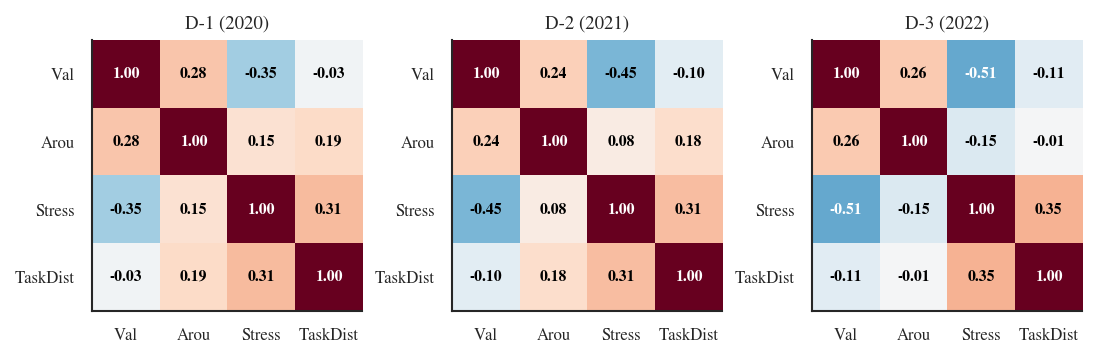

In [10]:
def compute_corr(wave_key: str) -> pd.DataFrame:
    df_wave = esm_by_wave.get(wave_key, pd.DataFrame())
    frame = pd.DataFrame({lbl: get_label_series(df_wave, lbl) for lbl in SHARED_LABELS})
    frame = frame.dropna(how="any")
    if frame.shape[0] < 5:
        return pd.DataFrame()
    corr = frame.corr(numeric_only=True)
    return corr.reindex(index=SHARED_LABELS, columns=SHARED_LABELS).astype(float)

short_labels = ["Val", "Arou", "Stress", "TaskDist"]
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), constrained_layout=True)
for ax, wave, wave_label in zip(axes, WAVE_KEYS, WAVE_LABELS):
    corr = compute_corr(wave)
    if corr.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_axis_off()
        continue
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(short_labels)))
    ax.set_yticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels)
    ax.set_yticklabels(short_labels)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color="white" if abs(val) > 0.5 else "black")
    ax.set_title(wave_label, fontsize=9, pad=6)
plt.show()

### Full Label Correlation Heatmaps by Wave

This section shows full pairwise label correlation heatmaps separately for each wave.


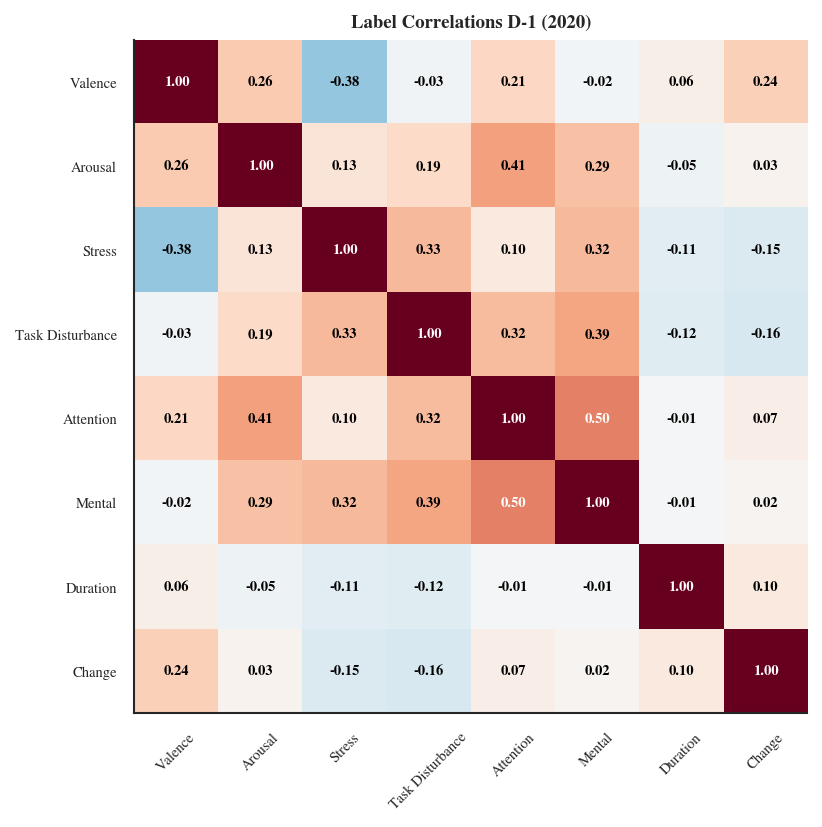

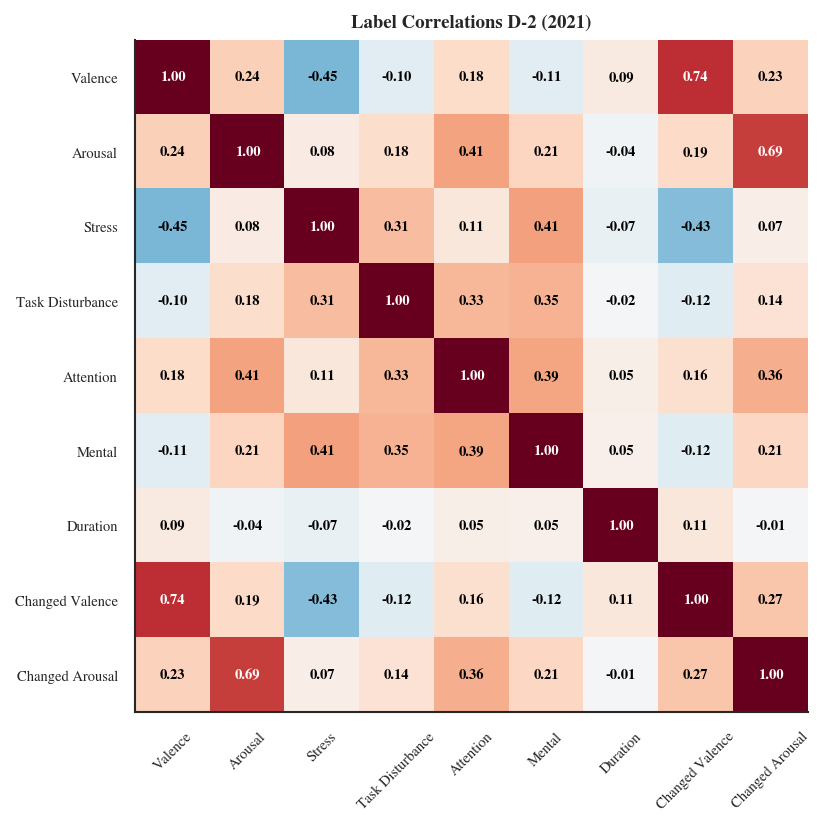

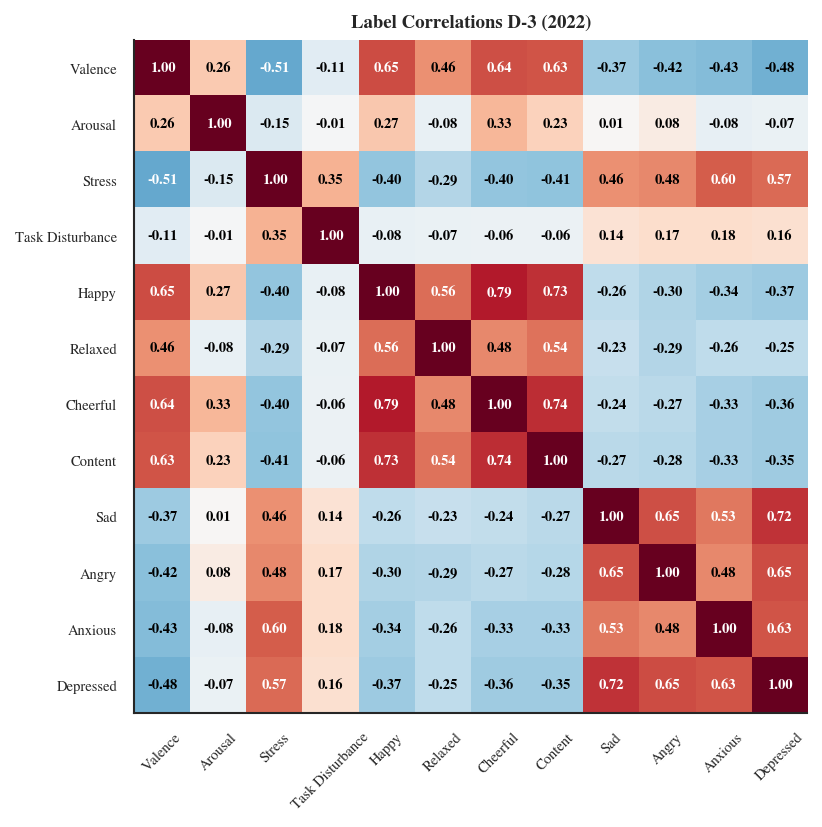

In [11]:
for wave in WAVE_KEYS:
    df_wave = esm_by_wave.get(wave, pd.DataFrame())
    present = [c for c in ALL_LABELS if c in df_wave.columns]

    frame = df_wave[present].apply(normalize_label_series)
    frame = frame.dropna(how="any")
    if frame.shape[0] < 5:
        continue

    corr = frame.corr(numeric_only=True).astype(float)
    fig, ax = plt.subplots(figsize=(6.4, 5.4), constrained_layout=True)
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns)
    ax.set_yticklabels(corr.index)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7.0, fontweight="bold", color="white" if abs(val) > 0.5 else "black")
    ax.set_title(f"Label Correlations {WAVE_LABELS[WAVE_KEYS.index(wave)]}", fontsize=9, pad=6, fontweight="bold")
    plt.show()

### Pairwise - ESM Label Correlations

This heatmap summarizes the pattern across waves so differences and missingness are easy to compare.


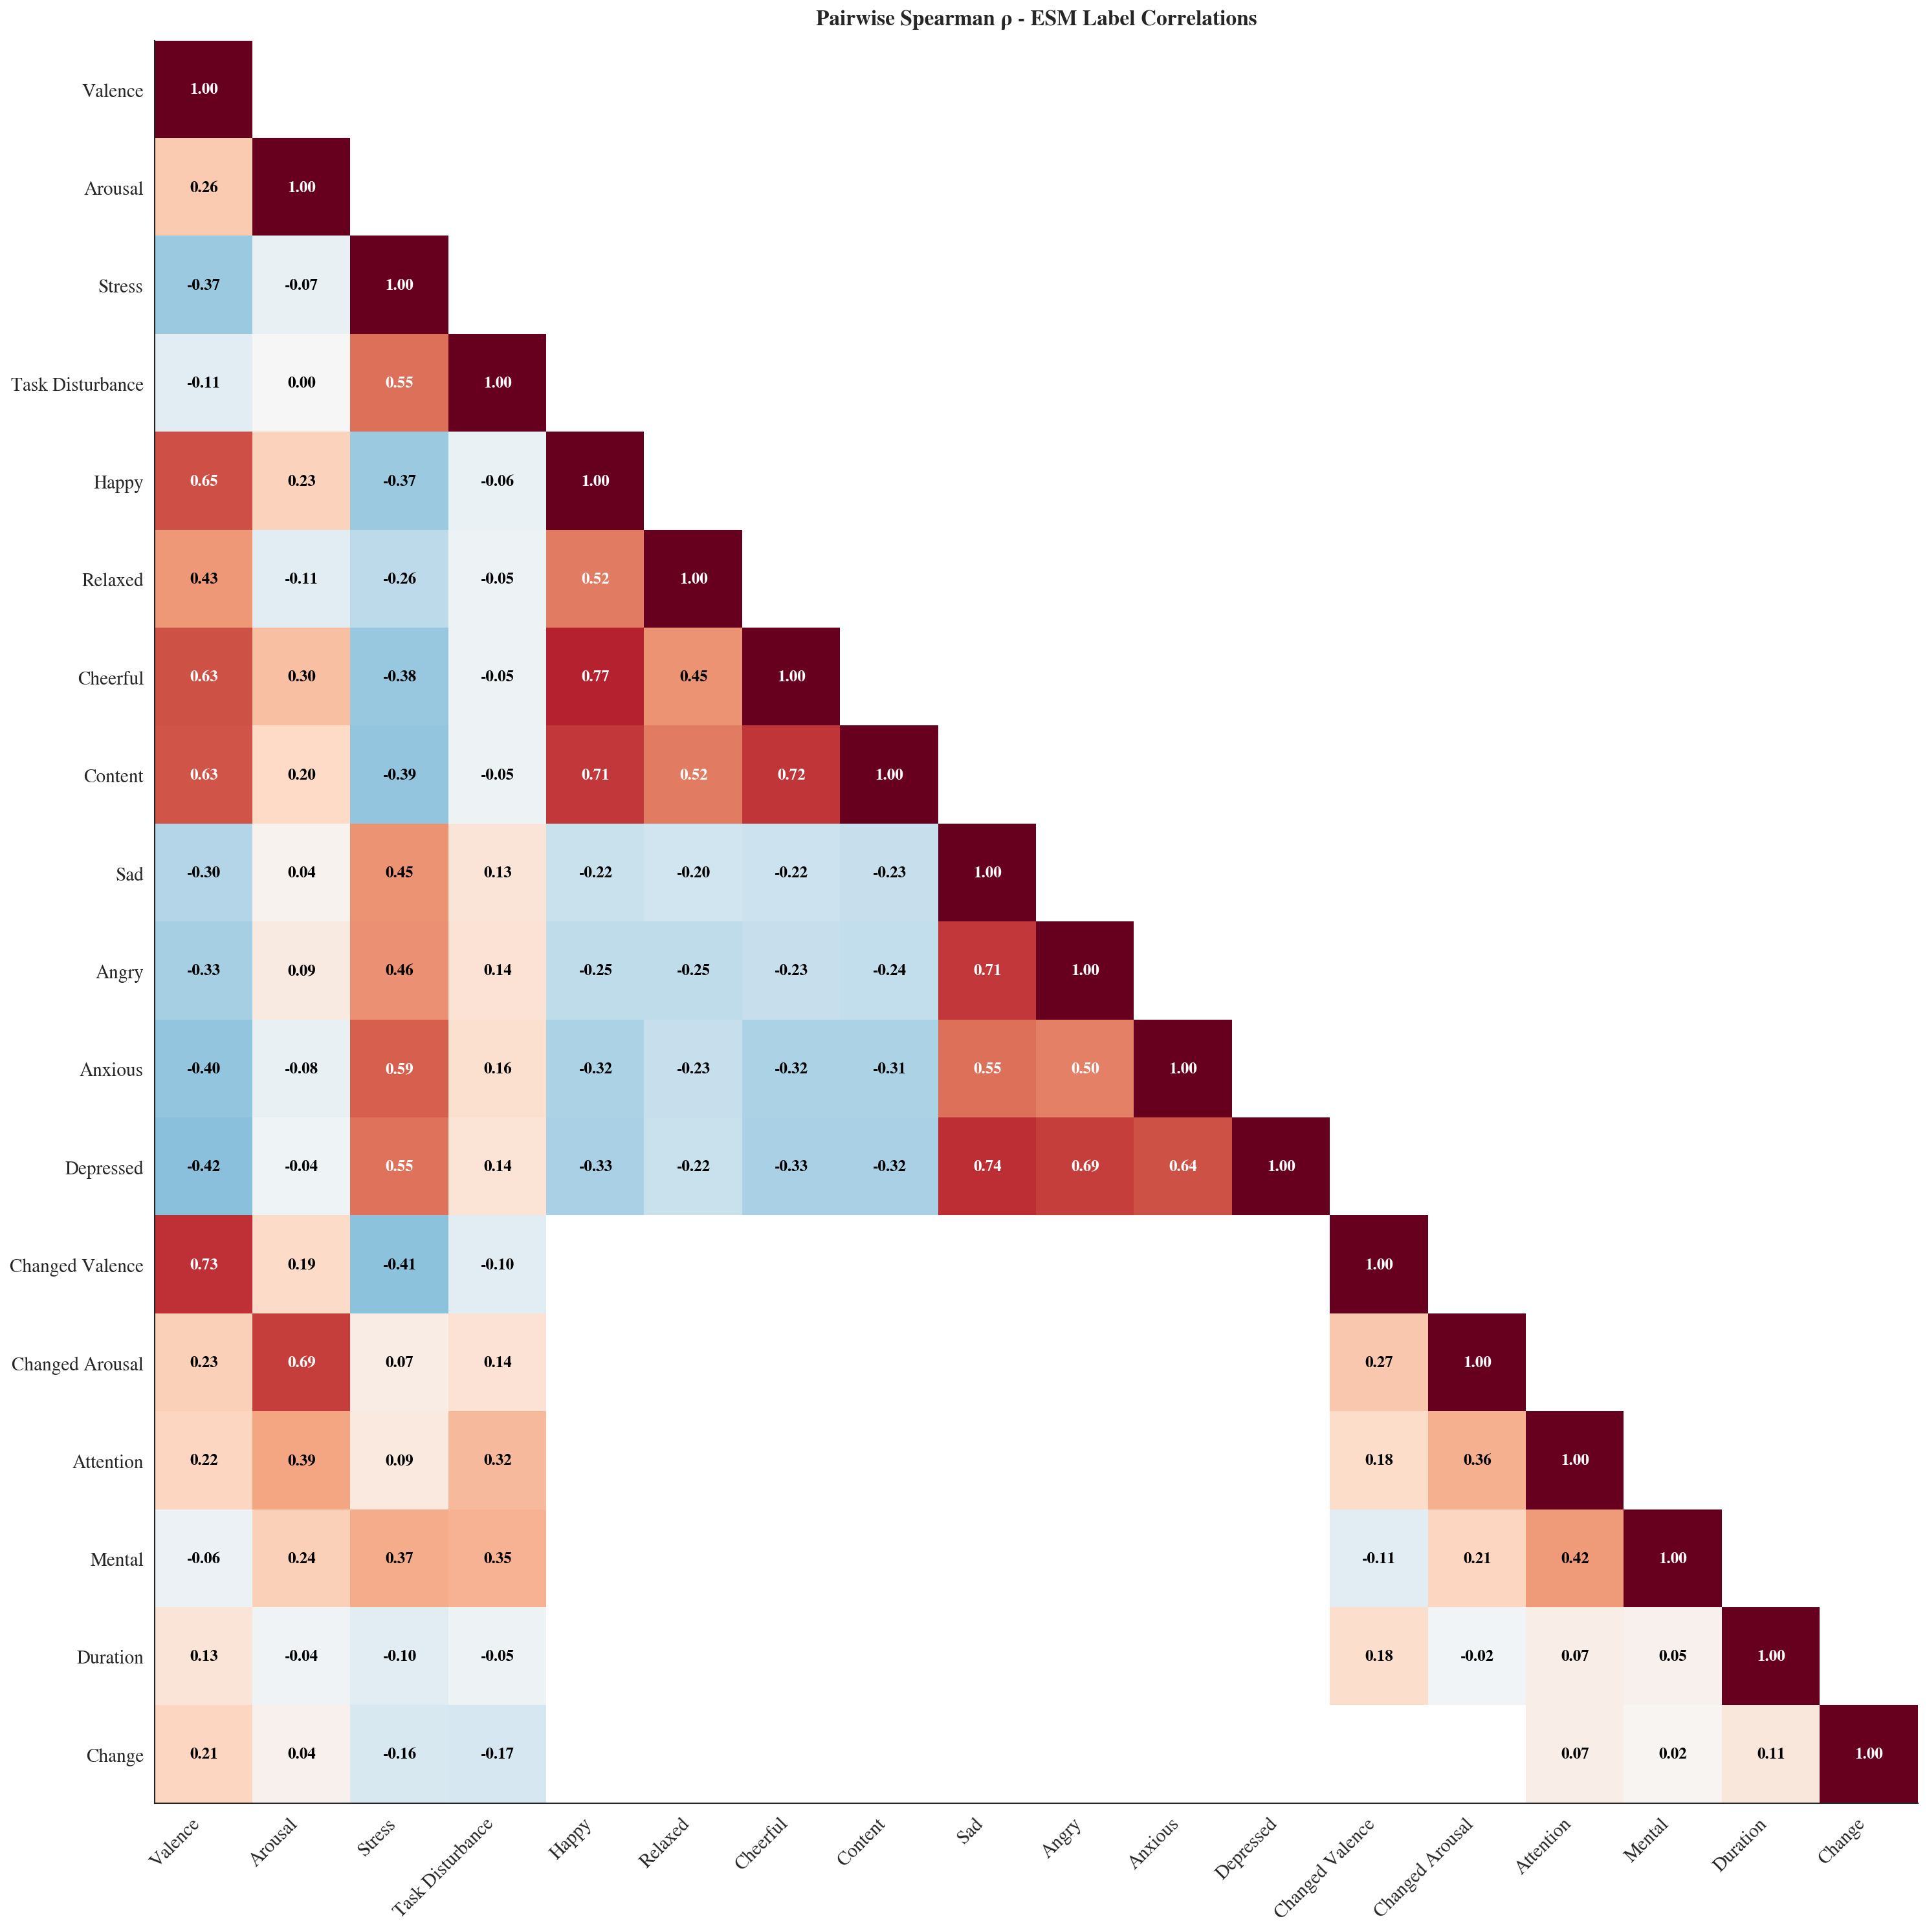

In [12]:
label_cols = [c for c in (SHARED_LABELS + W3_ONLY + W2_ONLY + W1_W2_ONLY + W1_ONLY)
              if c in esm_all.columns and esm_all[c].notna().sum() > 100]


corr = esm_all[label_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = corr.mask(mask)

fig, ax = plt.subplots(figsize=(len(label_cols) * 1 + 3, len(label_cols) * 1 + 2))
# (figsize=(len(label_cols) * 0.75 + 3, len(label_cols) * 0.75 + 2))
data = corr_masked.values
masked = np.ma.masked_invalid(data)
im = ax.imshow(masked, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(label_cols)))
ax.set_yticks(range(len(label_cols)))
ax.set_xticklabels(label_cols, rotation=45, ha="right", fontsize=14)
ax.set_yticklabels(label_cols, fontsize=14)

for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        val = corr_masked.values[i, j]
        if np.isnan(val):
            continue
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if abs(val) > 0.5 else "black")
ax.set_title("Pairwise Spearman ρ - ESM Label Correlations",
                fontsize=16, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### High-Label Ratio by Shared Label

This grouped bar chart shows the proportion of HIGH labels for each shared label across waves.


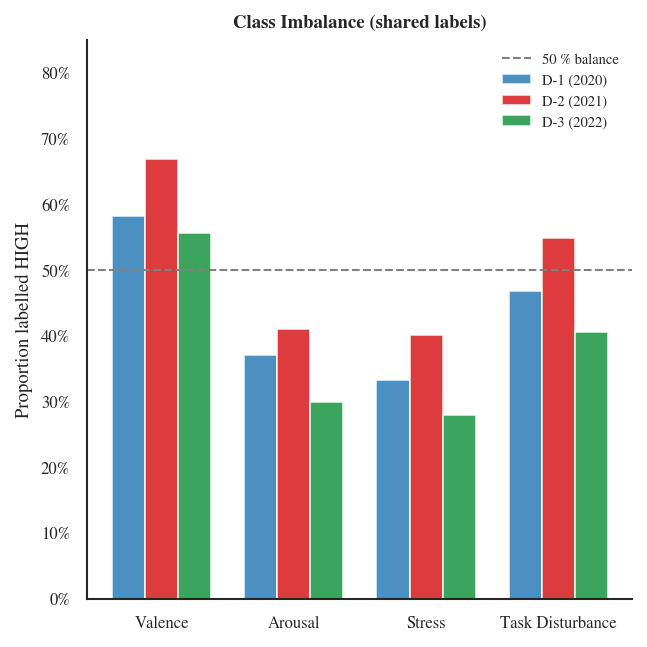

In [13]:
# Proportion of responses labelled HIGH (>0) per shared label per wave
high_ratios = {
    wave: [
        (get_label_series(esm_by_wave[wave], lbl) > 0).mean()
        if not get_label_series(esm_by_wave[wave], lbl).empty else np.nan
        for lbl in SHARED_LABELS
    ]
    for wave in WAVE_KEYS
}

fig, ax = plt.subplots(figsize=(4.2, 4.2), constrained_layout=True)
x     = np.arange(len(SHARED_LABELS))
width = 0.25

for i, (wave, ratios) in enumerate(high_ratios.items()):
    ax.bar(x + (i - 1) * width, ratios, width,
           label=WAVE_LABELS[i], color=COLORS[wave], alpha=0.85)

ax.axhline(0.5, color="gray", lw=1, ls="--", label="50 % balance")
ax.set_xticks(x)
ax.set_xticklabels(SHARED_LABELS)
ax.set_ylabel("Proportion labelled HIGH")
ax.set_ylim(0, 0.85)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Class Imbalance (shared labels)", fontweight="bold", fontsize=9)
ax.legend(fontsize=7, frameon=False)
plt.show()

### High vs Low Class Balance (Stacked Bars)

These stacked bars show HIGH and LOW class balance per shared label in each wave.


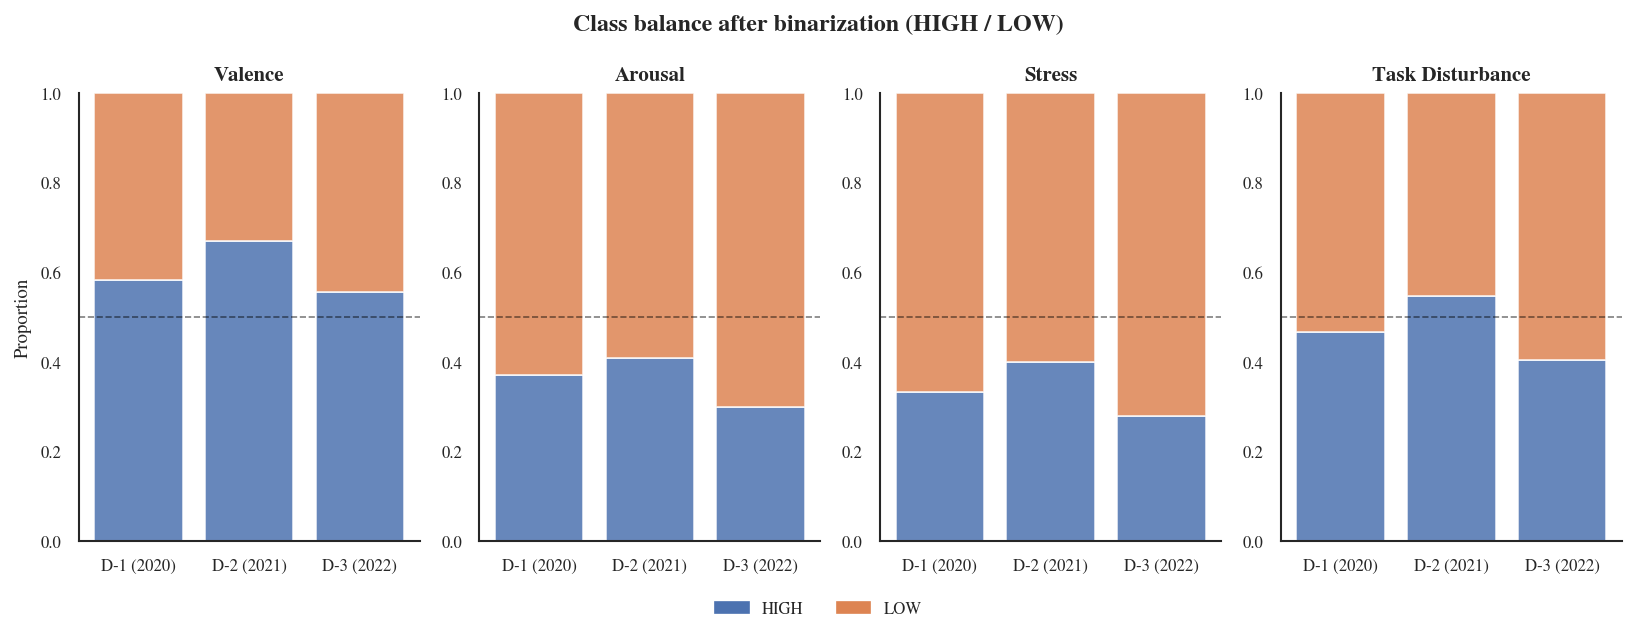

In [14]:
# Adapted from eda_visuals.py
fig, axes = plt.subplots(1, len(SHARED_LABELS), figsize=(11, 4))
fig.suptitle("Class balance after binarization (HIGH / LOW)", fontweight="bold")

for ax, lbl in zip(axes, SHARED_LABELS):
    fracs = []
    for wave in WAVE_KEYS:
        series = get_label_series(esm_by_wave.get(wave, pd.DataFrame()), lbl)
        if series.empty:
            fracs.append((0.5, 0.5))
        else:
            high = (series > 0).mean()
            fracs.append((high, 1 - high))

    x = np.arange(len(WAVE_KEYS))
    highs = [f[0] for f in fracs]
    lows  = [f[1] for f in fracs]
    ax.bar(x, highs, color="#4C72B0", label="HIGH", alpha=0.85)
    ax.bar(x, lows, bottom=highs, color="#DD8452", label="LOW", alpha=0.85)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(WAVE_LABELS)
    ax.set_ylim(0, 1)
    ax.set_title(lbl, fontweight="bold")
    if ax == axes[0]:
        ax.set_ylabel("Proportion")

handles = [
    mpatches.Patch(color="#4C72B0", label="HIGH"),
    mpatches.Patch(color="#DD8452", label="LOW"),
]
fig.legend(handles=handles, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()
